# E-Commerce Sales Analysis and Business Intelligence Dashboard

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
import random

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [8]:
np.random.seed(42)

countries = [
    "USA", "India", "UK", "Canada", "Australia",
    "Germany", "France", "Japan", "Singapore", "UAE"
]

genders = ["Male", "Female"]

customers = pd.DataFrame({
    "CustomerID": range(1, 501),
    "CustomerName": [f"Customer_{i}" for i in range(1, 501)],
    "Age": np.random.randint(18, 65, 500),
    "Gender": np.random.choice(genders, 500),
    "Country": np.random.choice(countries, 500),
    "RegistrationDate": pd.to_datetime("2022-01-01") +
                        pd.to_timedelta(np.random.randint(0, 1000, 500), unit="D")
})

customers.head()

,CustomerID,CustomerName,Age,Gender,Country,RegistrationDate
0,1,Customer_1,56,Male,Singapore,2024-03-13
1,2,Customer_2,46,Male,Germany,2022-05-11
2,3,Customer_3,32,Male,Japan,2023-05-13
3,4,Customer_4,60,Male,USA,2022-08-17
4,5,Customer_5,25,Male,UAE,2022-04-18


In [16]:
customers.to_csv("/tmp/customers.csv", index=False)

print("customers.csv saved successfully")


customers.csv saved successfully


In [17]:
categories = [
    "Electronics",
    "Clothing",
    "Home & Kitchen",
    "Sports",
    "Books",
    "Beauty",
    "Toys",
    "Accessories"
]

products = pd.DataFrame({
    "ProductID": range(1, 201),
    "ProductName": [f"Product_{i}" for i in range(1, 201)],
    "Category": np.random.choice(categories, 200),
    "Price": np.random.randint(10, 1000, 200),
    "CostPrice": np.random.randint(5, 700, 200)
})

products.head()

,ProductID,ProductName,Category,Price,CostPrice
0,1,Product_1,Home & Kitchen,413,418
1,2,Product_2,Books,814,118
2,3,Product_3,Accessories,525,149
3,4,Product_4,Sports,741,542
4,5,Product_5,Books,373,652


In [18]:
products.to_csv("/tmp/products.csv", index=False)

print("products.csv saved successfully")

products.csv saved successfully


In [19]:
orders = pd.DataFrame({
    "OrderID": range(1, 5001),
    "CustomerID": np.random.randint(1, 501, 5000),
    "ProductID": np.random.randint(1, 201, 5000),
    "Quantity": np.random.randint(1, 10, 5000),
    "Discount": np.round(np.random.uniform(0, 0.30, 5000), 2),
    "Region": np.random.choice(
        ["North America", "Asia", "Europe", "Middle East", "Oceania"],
        5000
    ),
    "OrderDate": pd.to_datetime("2023-01-01") +
                 pd.to_timedelta(np.random.randint(0, 730, 5000), unit="D")
})

orders.head()

,OrderID,CustomerID,ProductID,Quantity,Discount,Region,OrderDate
0,1,109,29,3,0.17,North America,2023-01-22
1,2,494,70,6,0.16,Oceania,2024-11-20
2,3,36,153,9,0.05,Middle East,2024-07-13
3,4,232,95,3,0.21,Middle East,2024-09-20
4,5,229,22,5,0.21,North America,2023-11-25


In [20]:
orders.to_csv("/tmp/orders.csv", index=False)

print("orders.csv saved successfully")

orders.csv saved successfully


In [21]:
payment_methods = [
    "Credit Card",
    "Debit Card",
    "UPI",
    "PayPal",
    "Net Banking",
    "Wallet"
]

payment_status = [
    "Completed",
    "Pending",
    "Failed",
    "Refunded"
]

payments = pd.DataFrame({
    "PaymentID": range(1, 5001),
    "OrderID": range(1, 5001),
    "PaymentMethod": np.random.choice(payment_methods, 5000),
    "PaymentStatus": np.random.choice(payment_status, 5000),
    "AmountPaid": np.random.randint(50, 5000, 5000)
})

payments.head()

,PaymentID,OrderID,PaymentMethod,PaymentStatus,AmountPaid
0,1,1,Credit Card,Pending,3768
1,2,2,PayPal,Completed,1674
2,3,3,Net Banking,Refunded,1856
3,4,4,Debit Card,Refunded,4408
4,5,5,PayPal,Completed,1504


In [22]:
payments.to_csv("/tmp/payments.csv", index=False)

print("payments.csv saved successfully")

payments.csv saved successfully


In [23]:
customers = pd.read_csv("/tmp/customers.csv")
products = pd.read_csv("/tmp/products.csv")
orders = pd.read_csv("/tmp/orders.csv")
payments = pd.read_csv("/tmp/payments.csv")

print("All datasets loaded successfully")

print("Customers Shape :", customers.shape)
print("Products Shape  :", products.shape)
print("Orders Shape    :", orders.shape)
print("Payments Shape  :", payments.shape)

All datasets loaded successfully
Customers Shape : (500, 6)
Products Shape  : (200, 5)
Orders Shape    : (5000, 7)
Payments Shape  : (5000, 5)


In [24]:
print("CUSTOMERS")
display(customers.head())

print("PRODUCTS")
display(products.head())

print("ORDERS")
display(orders.head())

print("PAYMENTS")
display(payments.head())

CUSTOMERS


,CustomerID,CustomerName,Age,Gender,Country,RegistrationDate
0,1,Customer_1,56,Male,Singapore,2024-03-13
1,2,Customer_2,46,Male,Germany,2022-05-11
2,3,Customer_3,32,Male,Japan,2023-05-13
3,4,Customer_4,60,Male,USA,2022-08-17
4,5,Customer_5,25,Male,UAE,2022-04-18


PRODUCTS


,ProductID,ProductName,Category,Price,CostPrice
0,1,Product_1,Home & Kitchen,413,418
1,2,Product_2,Books,814,118
2,3,Product_3,Accessories,525,149
3,4,Product_4,Sports,741,542
4,5,Product_5,Books,373,652


ORDERS


,OrderID,CustomerID,ProductID,Quantity,Discount,Region,OrderDate
0,1,109,29,3,0.17,North America,2023-01-22
1,2,494,70,6,0.16,Oceania,2024-11-20
2,3,36,153,9,0.05,Middle East,2024-07-13
3,4,232,95,3,0.21,Middle East,2024-09-20
4,5,229,22,5,0.21,North America,2023-11-25


PAYMENTS


,PaymentID,OrderID,PaymentMethod,PaymentStatus,AmountPaid
0,1,1,Credit Card,Pending,3768
1,2,2,PayPal,Completed,1674
2,3,3,Net Banking,Refunded,1856
3,4,4,Debit Card,Refunded,4408
4,5,5,PayPal,Completed,1504


In [25]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nOrders Missing Values")
print(orders.isnull().sum())

print("\nPayments Missing Values")
print(payments.isnull().sum())

Customers Missing Values
CustomerID          0
CustomerName        0
Age                 0
Gender              0
Country             0
RegistrationDate    0
dtype: int64

Products Missing Values
ProductID      0
ProductName    0
Category       0
Price          0
CostPrice      0
dtype: int64

Orders Missing Values
OrderID       0
CustomerID    0
ProductID     0
Quantity      0
Discount      0
Region        0
OrderDate     0
dtype: int64

Payments Missing Values
PaymentID        0
OrderID          0
PaymentMethod    0
PaymentStatus    0
AmountPaid       0
dtype: int64


In [26]:
print("Customers Duplicates :", customers.duplicated().sum())
print("Products Duplicates  :", products.duplicated().sum())
print("Orders Duplicates    :", orders.duplicated().sum())
print("Payments Duplicates  :", payments.duplicated().sum())

Customers Duplicates : 0
Products Duplicates  : 0
Orders Duplicates    : 0
Payments Duplicates  : 0


In [27]:
customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
orders.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)

customers.dropna(inplace=True)
products.dropna(inplace=True)
orders.dropna(inplace=True)
payments.dropna(inplace=True)

print("Data Cleaning Completed Successfully")

Data Cleaning Completed Successfully


In [28]:
merged_df = orders.merge(customers, on="CustomerID")
merged_df = merged_df.merge(products, on="ProductID")
merged_df = merged_df.merge(payments, on="OrderID")

merged_df.head()

,OrderID,CustomerID,ProductID,Quantity,Discount,Region,OrderDate,CustomerName,Age,Gender,Country,RegistrationDate,ProductName,Category,Price,CostPrice,PaymentID,PaymentMethod,PaymentStatus,AmountPaid
0,1,109,29,3,0.17,North America,2023-01-22,Customer_109,22,Male,USA,2023-12-23,Product_29,Beauty,380,328,1,Credit Card,Pending,3768
1,2,494,70,6,0.16,Oceania,2024-11-20,Customer_494,49,Female,USA,2022-11-05,Product_70,Beauty,847,16,2,PayPal,Completed,1674
2,3,36,153,9,0.05,Middle East,2024-07-13,Customer_36,61,Male,France,2024-09-02,Product_153,Books,285,616,3,Net Banking,Refunded,1856
3,4,232,95,3,0.21,Middle East,2024-09-20,Customer_232,50,Male,Japan,2024-04-29,Product_95,Toys,614,498,4,Debit Card,Refunded,4408
4,5,229,22,5,0.21,North America,2023-11-25,Customer_229,39,Male,France,2023-05-05,Product_22,Electronics,344,685,5,PayPal,Completed,1504


In [29]:
merged_df["TotalSales"] = merged_df["Quantity"] * merged_df["Price"]

merged_df["DiscountAmount"] = (
    merged_df["TotalSales"] * merged_df["Discount"]
)

merged_df["FinalAmount"] = (
    merged_df["TotalSales"] - merged_df["DiscountAmount"]
)

merged_df["Profit"] = (
    merged_df["FinalAmount"] - (merged_df["Quantity"] * merged_df["CostPrice"])
)

merged_df.head()

,OrderID,CustomerID,ProductID,Quantity,Discount,Region,OrderDate,CustomerName,Age,Gender,...,Price,CostPrice,PaymentID,PaymentMethod,PaymentStatus,AmountPaid,TotalSales,DiscountAmount,FinalAmount,Profit
0,1,109,29,3,0.17,North America,2023-01-22,Customer_109,22,Male,...,380,328,1,Credit Card,Pending,3768,1140,193.80,946.20,-37.80
1,2,494,70,6,0.16,Oceania,2024-11-20,Customer_494,49,Female,...,847,16,2,PayPal,Completed,1674,5082,813.12,4268.88,4172.88
2,3,36,153,9,0.05,Middle East,2024-07-13,Customer_36,61,Male,...,285,616,3,Net Banking,Refunded,1856,2565,128.25,2436.75,-3107.25
3,4,232,95,3,0.21,Middle East,2024-09-20,Customer_232,50,Male,...,614,498,4,Debit Card,Refunded,4408,1842,386.82,1455.18,-38.82
4,5,229,22,5,0.21,North America,2023-11-25,Customer_229,39,Male,...,344,685,5,PayPal,Completed,1504,1720,361.20,1358.80,-2066.20


In [30]:
print("Merged Dataset Shape:", merged_df.shape)

merged_df.info()

Merged Dataset Shape: (5000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           5000 non-null   int64  
 1   CustomerID        5000 non-null   int64  
 2   ProductID         5000 non-null   int64  
 3   Quantity          5000 non-null   int64  
 4   Discount          5000 non-null   float64
 5   Region            5000 non-null   object 
 6   OrderDate         5000 non-null   object 
 7   CustomerName      5000 non-null   object 
 8   Age               5000 non-null   int64  
 9   Gender            5000 non-null   object 
 10  Country           5000 non-null   object 
 11  RegistrationDate  5000 non-null   object 
 12  ProductName       5000 non-null   object 
 13  Category          5000 non-null   object 
 14  Price             5000 non-null   int64  
 15  CostPrice         5000 non-null   int64  
 16  PaymentID

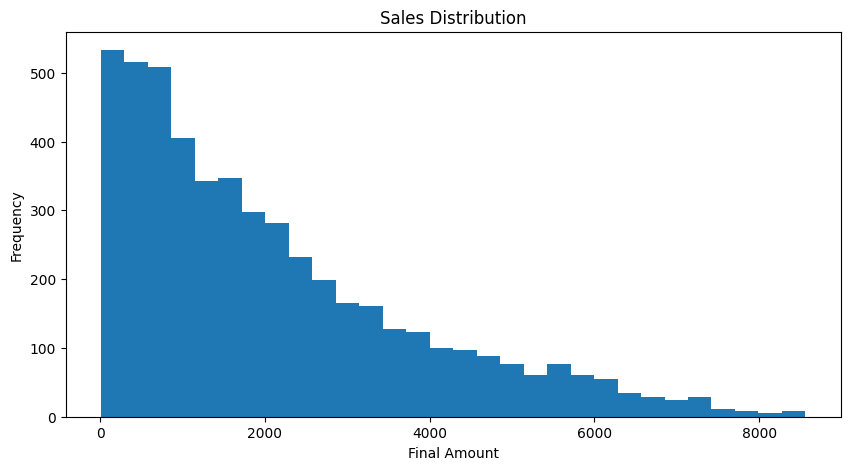

In [31]:
plt.figure(figsize=(10,5))

plt.hist(merged_df["FinalAmount"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Final Amount")
plt.ylabel("Frequency")

plt.show()

Category
Beauty            1955733.79
Sports            1481748.69
Accessories       1425249.34
Clothing          1248262.97
Electronics       1221926.87
Toys              1174490.86
Home & Kitchen    1020157.99
Books              881841.87
Name: FinalAmount, dtype: float64


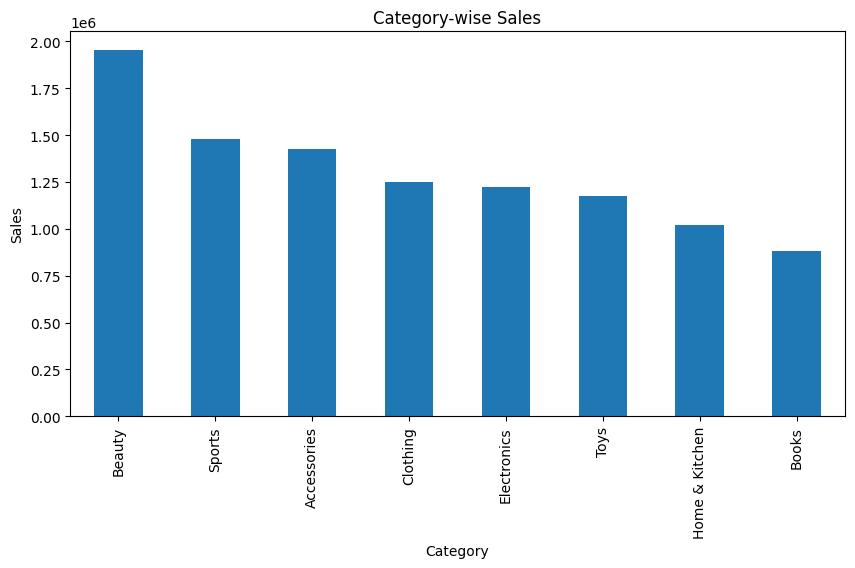

In [32]:
category_sales = merged_df.groupby("Category")["FinalAmount"].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(
    kind="bar",
    figsize=(10,5),
    title="Category-wise Sales"
)

plt.ylabel("Sales")
plt.show()

Country
Japan        1239240.58
Germany      1184708.54
USA          1145314.78
Canada       1045376.57
Australia    1041617.86
UK           1021395.54
UAE           993655.40
India         957834.15
France        941104.04
Singapore     839164.92
Name: FinalAmount, dtype: float64


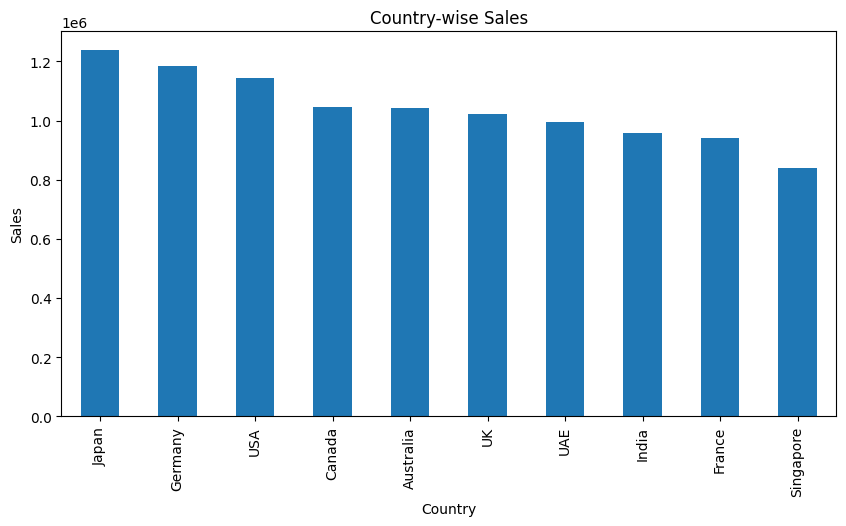

In [33]:
country_sales = merged_df.groupby("Country")["FinalAmount"].sum().sort_values(ascending=False)

print(country_sales)

country_sales.plot(
    kind="bar",
    figsize=(10,5),
    title="Country-wise Sales"
)

plt.ylabel("Sales")
plt.show()

CustomerName
Customer_405    55955.18
Customer_313    55296.41
Customer_13     51356.29
Customer_264    49463.41
Customer_451    47919.04
Customer_403    45885.52
Customer_424    44099.53
Customer_400    44056.65
Customer_314    43158.14
Customer_22     43091.40
Name: FinalAmount, dtype: float64


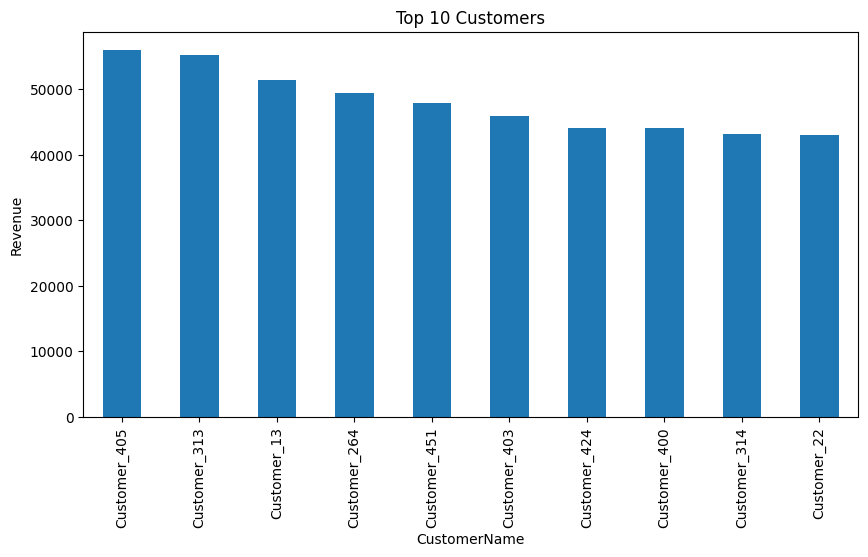

In [34]:
top_customers = merged_df.groupby(
    "CustomerName"
)["FinalAmount"].sum().sort_values(
    ascending=False
).head(10)

print(top_customers)

top_customers.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Customers"
)

plt.ylabel("Revenue")
plt.show()

In [35]:
group_analysis = merged_df.groupby("Category").agg({
    "FinalAmount":"sum",
    "Profit":"sum",
    "Quantity":"sum"
})

group_analysis

,FinalAmount,Profit,Quantity
Category,,,
Accessories,1425249.34,340055.34,3139
Beauty,1955733.79,622586.79,4190
Books,881841.87,-93731.13,2475
Clothing,1248262.97,368924.97,3225
Electronics,1221926.87,-147666.13,3303
Home & Kitchen,1020157.99,97749.99,2380
Sports,1481748.69,230329.69,3076
Toys,1174490.86,-142014.14,3170


In [36]:
multi_group = merged_df.groupby(
    ["Country","Category"]
).agg({
    "FinalAmount":"sum",
    "Profit":"sum"
})

multi_group.head(20)

FinalAmount    Profit
Country   Category                             
Australia Accessories       155666.49  13885.49
          Beauty            178963.13  56283.13
          Books              96321.75 -13532.25
          Clothing          118262.88  18422.88
          Electronics       126323.16  -7330.84
          Home & Kitchen    102441.74  19736.74
          Sports            117590.77  30656.77
          Toys              146047.94   6513.94
Canada    Accessories       168283.34  51876.34
          Beauty            195653.84  78584.84
          Books              73128.51  -8426.49
          Clothing          108895.75  18911.75
          Electronics       134824.32  -9025.68
          Home & Kitchen    106950.39   5960.39
          Sports            138228.89   9155.89
          Toys              119411.53   3715.53
France    Accessories        85577.57  12925.57
          Beauty            168727.54  55682.54
          Books              96759.53 -19860.47
          Clothing          127889.76  54739.76

In [37]:
pivot_table = pd.pivot_table(
    merged_df,
    values="FinalAmount",
    index="Country",
    columns="Category",
    aggfunc="sum"
)

pivot_table

Category,Accessories,Beauty,Books,Clothing,Electronics,Home & Kitchen,Sports,Toys
Country,,,,,,,,
Australia,155666.49,178963.13,96321.75,118262.88,126323.16,102441.74,117590.77,146047.94
Canada,168283.34,195653.84,73128.51,108895.75,134824.32,106950.39,138228.89,119411.53
France,85577.57,168727.54,96759.53,127889.76,147239.64,88000.99,140874.27,86034.74
Germany,168051.26,265491.54,108756.64,102035.45,126809.03,130227.88,161433.99,121902.75
India,144338.51,203833.90,90898.64,101388.86,93096.66,68165.75,161903.05,94208.78
Japan,171073.27,180658.67,76216.19,159942.69,161451.81,113511.78,221444.55,154941.62
Singapore,124169.92,140740.33,76037.24,120407.84,102488.55,75796.73,110297.09,89227.22
UAE,131546.76,183673.97,98162.06,138891.72,90868.88,77303.27,141659.68,131549.06
UK,134184.13,223061.40,74460.50,105103.94,107185.20,132998.03,137886.32,106516.02


In [38]:
print("Mean Sales :", merged_df["FinalAmount"].mean())
print("Median Sales :", merged_df["FinalAmount"].median())
print("Maximum Sales :", merged_df["FinalAmount"].max())
print("Minimum Sales :", merged_df["FinalAmount"].min())
print("Standard Deviation :", merged_df["FinalAmount"].std())
print("Variance :", merged_df["FinalAmount"].var())

Mean Sales : 2081.8824759999998
Median Sales : 1589.76
Maximum Sales : 8562.51
Minimum Sales : 8.7
Standard Deviation : 1766.3011888334458
Variance : 3119819.889674444


In [39]:
correlation_matrix = merged_df[
    ["Quantity","Price","CostPrice","TotalSales","FinalAmount","Profit"]
].corr()

correlation_matrix

,Quantity,Price,CostPrice,TotalSales,FinalAmount,Profit
Quantity,1.000000,0.006842,-0.034229,0.613595,0.608358,0.093541
Price,0.006842,1.000000,0.059674,0.704751,0.693788,0.651229
CostPrice,-0.034229,0.059674,1.000000,0.015492,0.014589,-0.544175
TotalSales,0.613595,0.704751,0.015492,1.000000,0.988491,0.641555
FinalAmount,0.608358,0.693788,0.014589,0.988491,1.000000,0.655960
Profit,0.093541,0.651229,-0.544175,0.641555,0.655960,1.000000


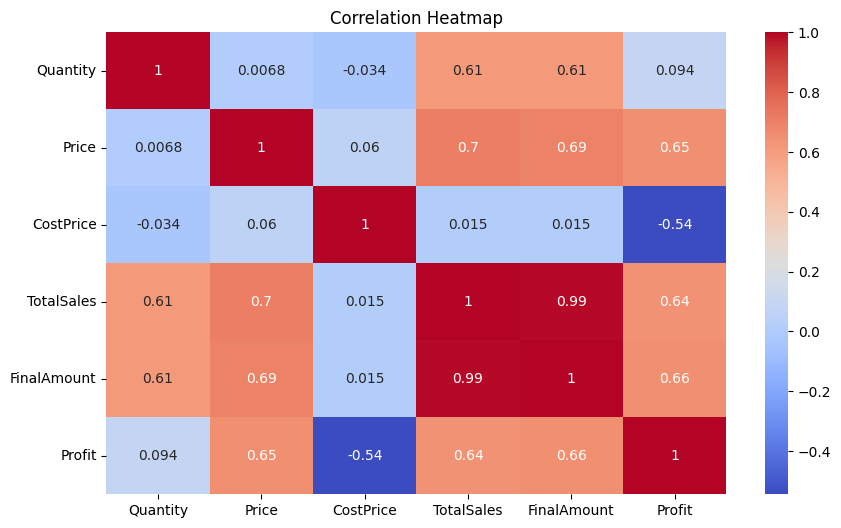

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [41]:
from scipy.stats import ttest_ind

electronics = merged_df[
    merged_df["Category"] == "Electronics"
]["FinalAmount"]

clothing = merged_df[
    merged_df["Category"] == "Clothing"
]["FinalAmount"]

t_stat, p_value = ttest_ind(
    electronics,
    clothing,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : -1.8348497372594825
P-Value : 0.06675914884815974


In [42]:
merged_df["OrderDate"] = pd.to_datetime(
    merged_df["OrderDate"]
)

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   OrderID           5000 non-null   int64         
 1   CustomerID        5000 non-null   int64         
 2   ProductID         5000 non-null   int64         
 3   Quantity          5000 non-null   int64         
 4   Discount          5000 non-null   float64       
 5   Region            5000 non-null   object        
 6   OrderDate         5000 non-null   datetime64[ns]
 7   CustomerName      5000 non-null   object        
 8   Age               5000 non-null   int64         
 9   Gender            5000 non-null   object        
 10  Country           5000 non-null   object        
 11  RegistrationDate  5000 non-null   object        
 12  ProductName       5000 non-null   object        
 13  Category          5000 non-null   object        
 14  Price             5000 n

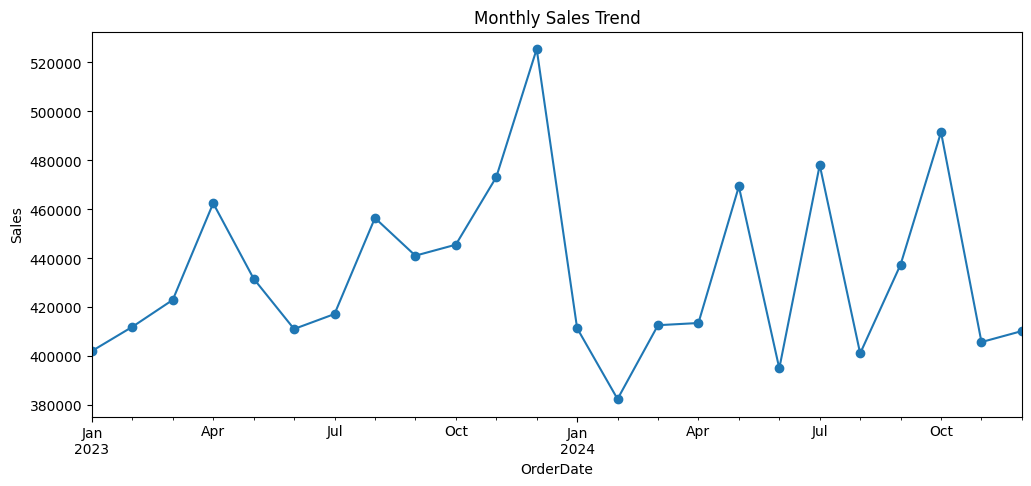

In [43]:
monthly_sales = merged_df.groupby(
    merged_df["OrderDate"].dt.to_period("M")
)["FinalAmount"].sum()

monthly_sales.plot(
    figsize=(12,5),
    marker="o",
    title="Monthly Sales Trend"
)

plt.ylabel("Sales")
plt.show()

OrderDate
2023    5300972.68
2024    5108439.70
Name: FinalAmount, dtype: float64


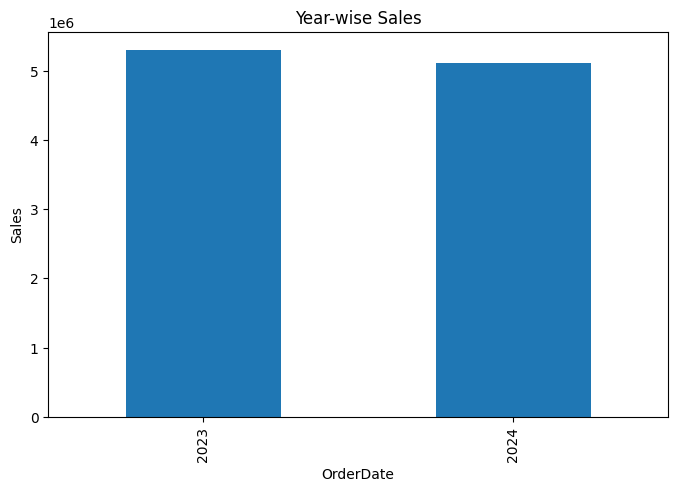

In [44]:
yearly_sales = merged_df.groupby(
    merged_df["OrderDate"].dt.year
)["FinalAmount"].sum()

print(yearly_sales)

yearly_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Year-wise Sales"
)

plt.ylabel("Sales")
plt.show()

ProductName
Product_70     130725.98
Product_82     125333.62
Product_182    123806.41
Product_103    123025.20
Product_109    122928.25
Product_177    122198.52
Product_105    118210.50
Product_85     118032.32
Product_94     116951.34
Product_56     113735.23
Name: FinalAmount, dtype: float64


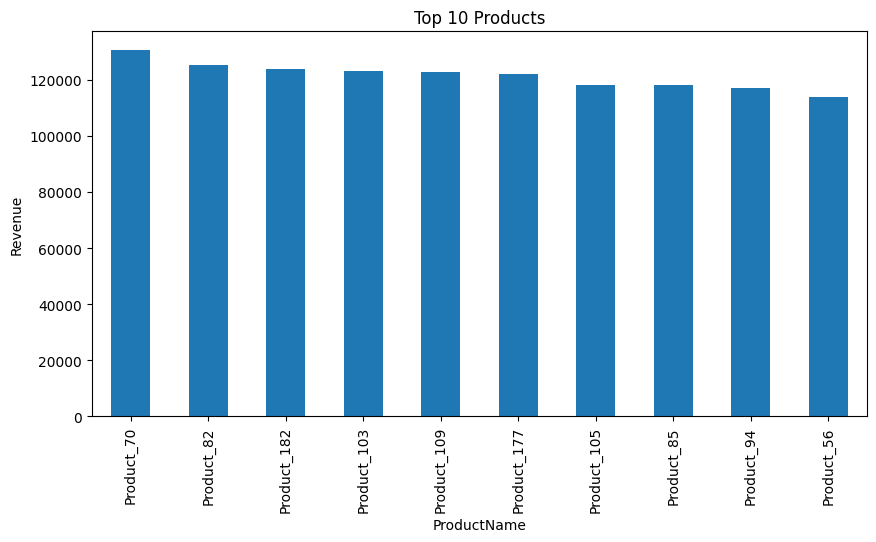

In [45]:
top_products = merged_df.groupby(
    "ProductName"
)["FinalAmount"].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

top_products.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Products"
)

plt.ylabel("Revenue")
plt.show()

PaymentMethod
UPI            1856573.60
Debit Card     1749813.30
Wallet         1744806.74
Net Banking    1733617.28
Credit Card    1676965.59
PayPal         1647635.87
Name: FinalAmount, dtype: float64


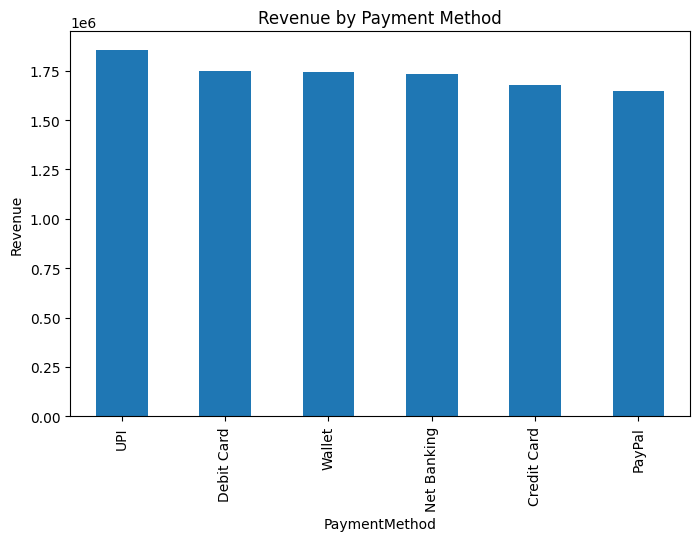

In [46]:
payment_analysis = merged_df.groupby(
    "PaymentMethod"
)["FinalAmount"].sum().sort_values(
    ascending=False
)

print(payment_analysis)

payment_analysis.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Payment Method"
)

plt.ylabel("Revenue")
plt.show()

In [47]:
def revenue_category(amount):
    if amount >= 3000:
        return "High"
    elif amount >= 1000:
        return "Medium"
    else:
        return "Low"

merged_df["RevenueCategory"] = merged_df["FinalAmount"].apply(
    revenue_category
)

merged_df[["FinalAmount","RevenueCategory"]].head()

,FinalAmount,RevenueCategory
0,946.20,Low
1,4268.88,High
2,2436.75,Medium
3,1455.18,Medium
4,1358.80,Medium


In [48]:
region_map = {
    "Asia":1,
    "Europe":2,
    "North America":3,
    "Middle East":4,
    "Oceania":5
}

merged_df["RegionCode"] = merged_df["Region"].map(
    region_map
)

merged_df[["Region","RegionCode"]].head()

,Region,RegionCode
0,North America,3
1,Oceania,5
2,Middle East,4
3,Middle East,4
4,North America,3


RevenueCategory
Medium    1967
Low       1770
High      1263
Name: count, dtype: int64


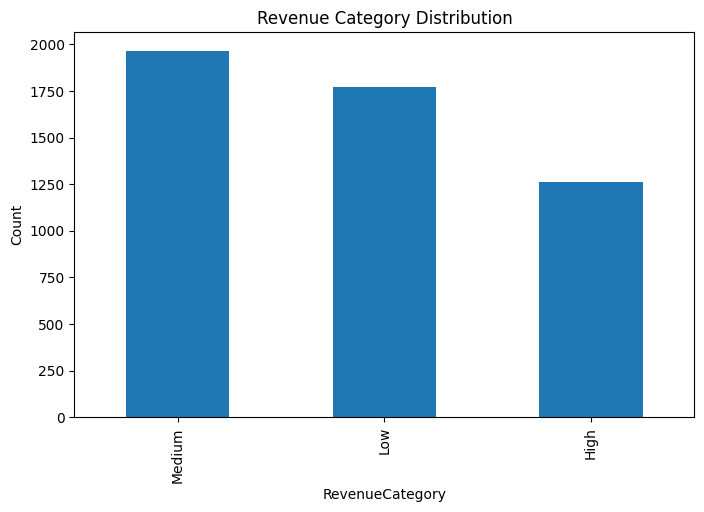

In [49]:
revenue_dist = merged_df["RevenueCategory"].value_counts()

print(revenue_dist)

revenue_dist.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue Category Distribution"
)

plt.ylabel("Count")
plt.show()

In [50]:
advanced_pivot = pd.pivot_table(
    merged_df,
    values="FinalAmount",
    index="Country",
    columns="RevenueCategory",
    aggfunc="sum",
    fill_value=0
)

advanced_pivot

RevenueCategory,High,Low,Medium
Country,,,
Australia,582165.68,87105.71,372346.47
Canada,604861.38,76824.17,363691.02
France,542393.66,71640.09,327070.29
Germany,639692.04,102961.78,442054.72
India,551643.92,81297.88,324892.35
Japan,737331.69,91990.21,409918.68
Singapore,407716.56,85734.90,345713.46
UAE,556905.59,86681.71,350068.10
UK,573530.57,85893.67,361971.30


In [51]:
sql_analysis = merged_df.groupby(
    "Country"
).agg(
    Total_Revenue=("FinalAmount","sum"),
    Average_Revenue=("FinalAmount","mean"),
    Total_Orders=("OrderID","count")
).sort_values(
    by="Total_Revenue",
    ascending=False
)

sql_analysis.head(10)

,Total_Revenue,Average_Revenue,Total_Orders
Country,,,
Japan,1239240.58,2121.987295,584
Germany,1184708.54,2049.668754,578
USA,1145314.78,2148.808218,533
Canada,1045376.57,2146.563799,487
Australia,1041617.86,2050.428858,508
UK,1021395.54,2136.810753,478
UAE,993655.40,2044.558436,486
India,957834.15,2109.766850,454
France,941104.04,2114.840539,445


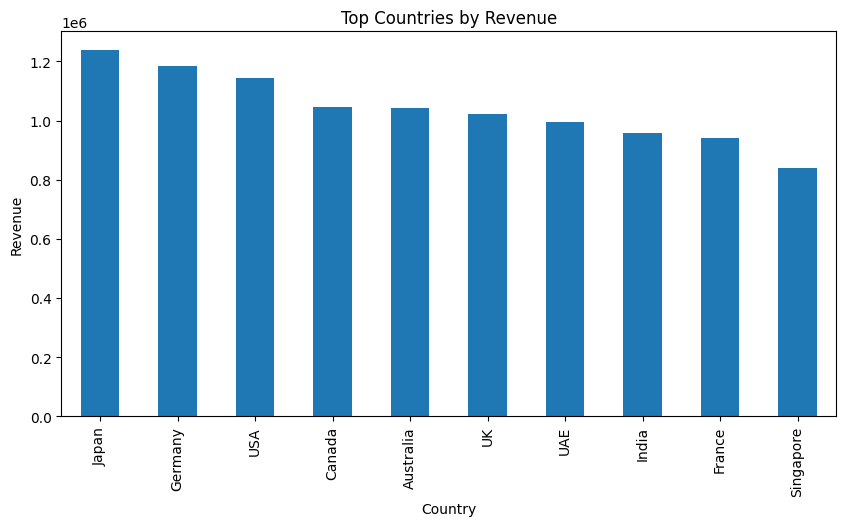

In [52]:
top_countries = merged_df.groupby(
    "Country"
)["FinalAmount"].sum().sort_values(
    ascending=False
)

top_countries.plot(
    kind="bar",
    figsize=(10,5),
    title="Top Countries by Revenue"
)

plt.ylabel("Revenue")
plt.show()

In [53]:
ml_data = merged_df[[
    "Quantity",
    "Price",
    "CostPrice",
    "Discount",
    "FinalAmount"
]]

ml_data.head()

,Quantity,Price,CostPrice,Discount,FinalAmount
0,3,380,328,0.17,946.20
1,6,847,16,0.16,4268.88
2,9,285,616,0.05,2436.75
3,3,614,498,0.21,1455.18
4,5,344,685,0.21,1358.80


In [54]:
X = ml_data[[
    "Quantity",
    "Price",
    "CostPrice",
    "Discount"
]]

y = ml_data["FinalAmount"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5000, 4)
Target Shape : (5000,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (4000, 4)
Testing Data : (1000, 4)


In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [57]:
y_pred = model.predict(X_test)

print("First 10 Predictions")

for i in range(10):
    print(
        "Actual:",
        round(y_test.iloc[i], 2),
        "| Predicted:",
        round(y_pred[i], 2)
    )

First 10 Predictions
Actual: 3017.8 | Predicted: 3485.59
Actual: 384.56 | Predicted: 247.2
Actual: 4096.98 | Predicted: 3963.52
Actual: 1441.52 | Predicted: 1368.27
Actual: 3041.28 | Predicted: 3394.15
Actual: 400.34 | Predicted: 342.08
Actual: 664.32 | Predicted: 1567.43
Actual: 146.25 | Predicted: -1100.16
Actual: 303.75 | Predicted: 239.5
Actual: 307.1 | Predicted: -131.77


In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 473.5722533863843
MSE : 395529.94009434845
R2 Score : 0.8622169482556393


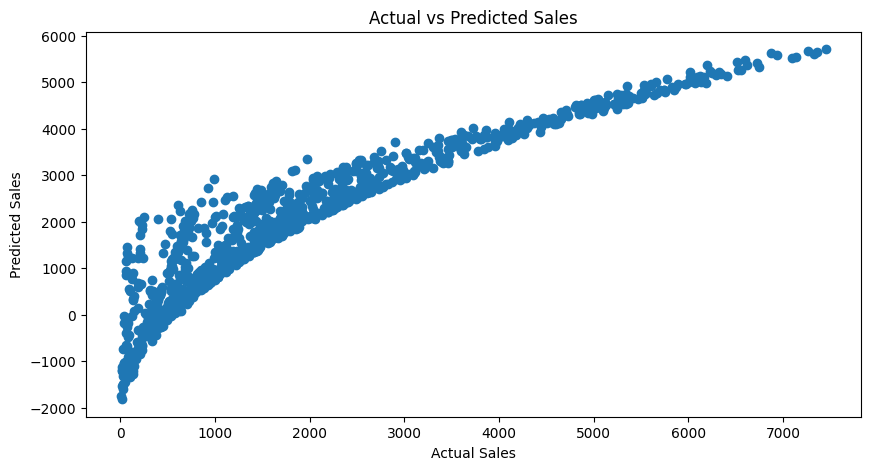

In [59]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [61]:
print("BUSINESS INSIGHTS")

print("1. Identified top-performing product categories.")
print("2. Analyzed country-wise revenue generation.")
print("3. Measured profitability across products.")
print("4. Studied customer purchasing behavior.")
print("5. Performed statistical analysis and hypothesis testing.")
print("6. Generated time-series sales trends.")
print("7. Built a machine learning model for sales prediction.")

BUSINESS INSIGHTS
1. Identified top-performing product categories.
2. Analyzed country-wise revenue generation.
3. Measured profitability across products.
4. Studied customer purchasing behavior.
5. Performed statistical analysis and hypothesis testing.
6. Generated time-series sales trends.
7. Built a machine learning model for sales prediction.


In [62]:
print("""
PROJECT CONCLUSION

This project successfully demonstrates the complete
data analysis lifecycle including data generation,
data cleaning, exploratory data analysis,
advanced pandas operations, feature creation,
SQL-style analysis, statistics, time-series analysis,
machine learning, and business insight generation.

The project provides a strong foundation for
business intelligence and decision-making.
""")


PROJECT CONCLUSION

This project successfully demonstrates the complete
data analysis lifecycle including data generation,
data cleaning, exploratory data analysis,
advanced pandas operations, feature creation,
SQL-style analysis, statistics, time-series analysis,
machine learning, and business insight generation.

The project provides a strong foundation for
business intelligence and decision-making.



In [63]:
merged_df["ProfitMargin"] = (
    merged_df["Profit"] / merged_df["FinalAmount"]
) * 100

merged_df[["Profit","FinalAmount","ProfitMargin"]].head()

,Profit,FinalAmount,ProfitMargin
0,-37.80,946.20,-3.994927
1,4172.88,4268.88,97.751167
2,-3107.25,2436.75,-127.516159
3,-38.82,1455.18,-2.667711
4,-2066.20,1358.80,-152.060642


In [64]:
customer_revenue = merged_df.groupby(
    "CustomerName"
)["FinalAmount"].sum()

def segment(x):
    if x >= 30000:
        return "Premium"
    elif x >= 15000:
        return "Regular"
    else:
        return "Basic"

customer_segment = customer_revenue.apply(segment)

customer_segment.value_counts()

FinalAmount
Regular    294
Basic      139
Premium     67
Name: count, dtype: int64

ProductName
Product_70     127829.98
Product_109    107700.25
Product_85      99277.32
Product_134     92199.72
Product_125     91839.52
Product_2       85527.26
Product_139     82657.72
Product_106     82590.36
Product_182     82010.41
Product_49      78396.32
Name: Profit, dtype: float64


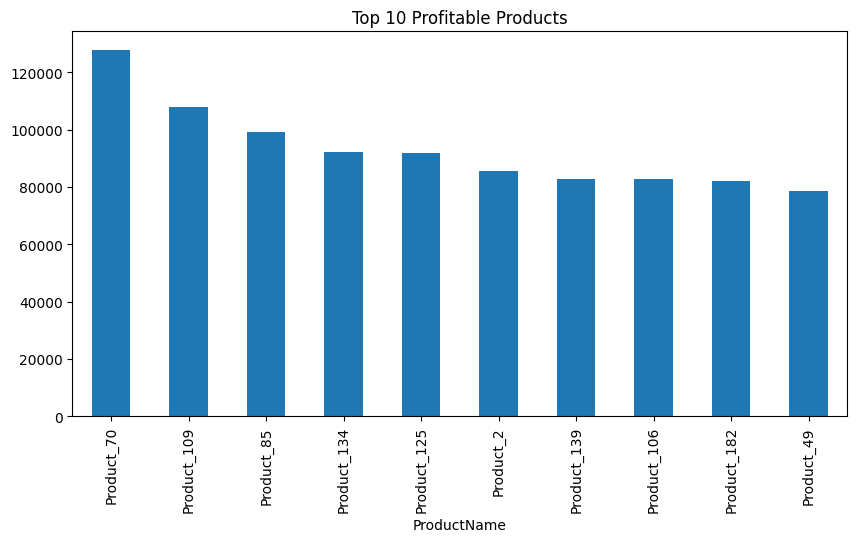

In [65]:
top_profit_products = merged_df.groupby(
    "ProductName"
)["Profit"].sum().sort_values(
    ascending=False
).head(10)

print(top_profit_products)

top_profit_products.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Profitable Products"
)

plt.show()

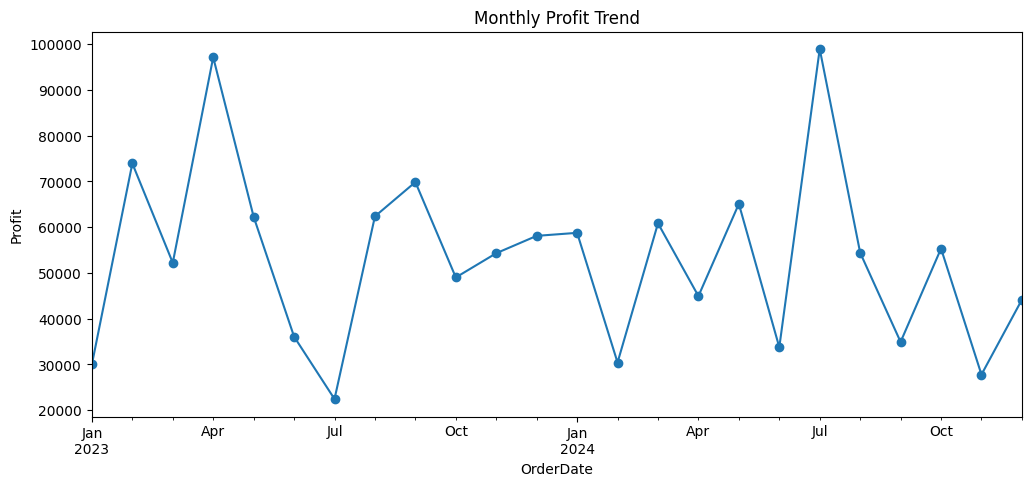

In [66]:
monthly_profit = merged_df.groupby(
    merged_df["OrderDate"].dt.to_period("M")
)["Profit"].sum()

monthly_profit.plot(
    figsize=(12,5),
    marker="o",
    title="Monthly Profit Trend"
)

plt.ylabel("Profit")
plt.show()

In [75]:
merged_df["AgeGroup"] = pd.cut(
    merged_df["Age"],
    bins=[18,25,35,45,60,101],
    labels=["18-25","26-35","36-45","46-60","60+"],
    include_lowest=True
)

PaymentStatus
Completed    2488346.19
Failed       2599085.65
Pending      2704427.31
Refunded     2617553.23
Name: FinalAmount, dtype: float64


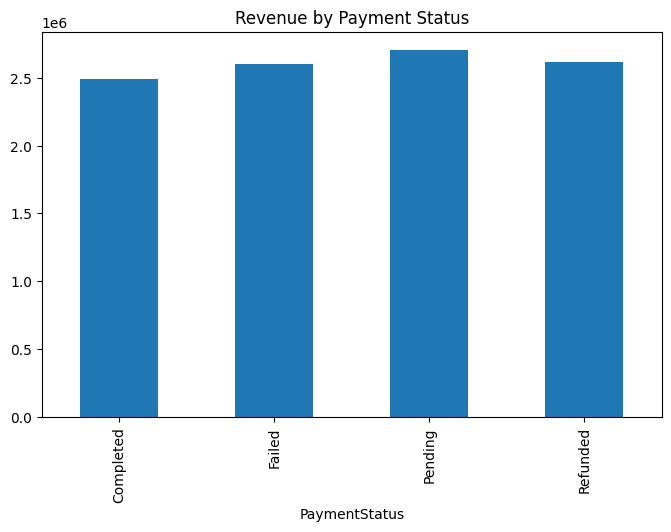

In [69]:
payment_status_analysis = merged_df.groupby(
    "PaymentStatus"
)["FinalAmount"].sum()

print(payment_status_analysis)

payment_status_analysis.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Payment Status"
)

plt.show()

In [70]:
country_category = pd.pivot_table(
    merged_df,
    values="FinalAmount",
    index="Country",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

country_category

Category,Accessories,Beauty,Books,Clothing,Electronics,Home & Kitchen,Sports,Toys
Country,,,,,,,,
Australia,155666.49,178963.13,96321.75,118262.88,126323.16,102441.74,117590.77,146047.94
Canada,168283.34,195653.84,73128.51,108895.75,134824.32,106950.39,138228.89,119411.53
France,85577.57,168727.54,96759.53,127889.76,147239.64,88000.99,140874.27,86034.74
Germany,168051.26,265491.54,108756.64,102035.45,126809.03,130227.88,161433.99,121902.75
India,144338.51,203833.90,90898.64,101388.86,93096.66,68165.75,161903.05,94208.78
Japan,171073.27,180658.67,76216.19,159942.69,161451.81,113511.78,221444.55,154941.62
Singapore,124169.92,140740.33,76037.24,120407.84,102488.55,75796.73,110297.09,89227.22
UAE,131546.76,183673.97,98162.06,138891.72,90868.88,77303.27,141659.68,131549.06
UK,134184.13,223061.40,74460.50,105103.94,107185.20,132998.03,137886.32,106516.02


CustomerName
Customer_405    55955.18
Customer_313    55296.41
Customer_13     51356.29
Customer_264    49463.41
Customer_451    47919.04
Customer_403    45885.52
Customer_424    44099.53
Customer_400    44056.65
Customer_314    43158.14
Customer_22     43091.40
Name: FinalAmount, dtype: float64


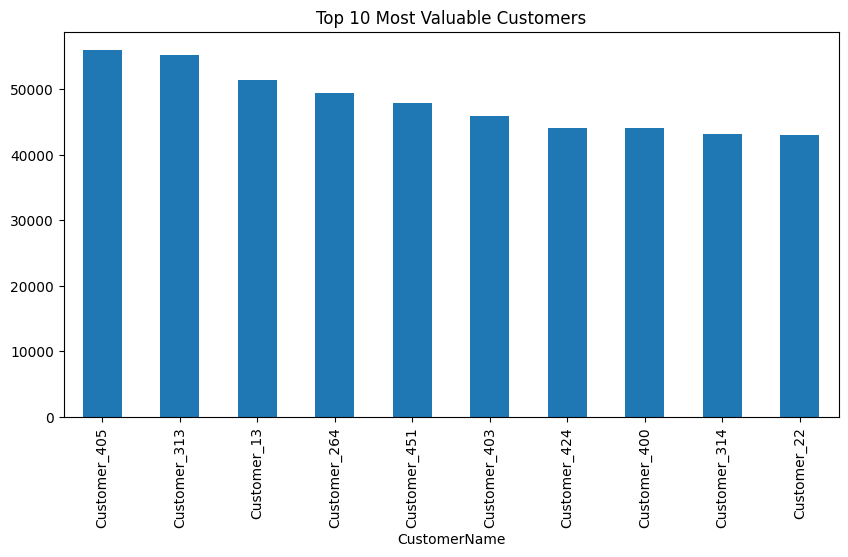

In [71]:
top_customers = merged_df.groupby(
    "CustomerName"
)["FinalAmount"].sum().sort_values(
    ascending=False
).head(10)

print(top_customers)

top_customers.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Most Valuable Customers"
)

plt.show()

In [72]:
print("""
==========================================
PROJECT COMPLETED SUCCESSFULLY
==========================================

Topics Covered:

✓ Data Cleaning
✓ Data Preprocessing
✓ Exploratory Data Analysis
✓ Matplotlib
✓ Seaborn
✓ Advanced Pandas
✓ GroupBy
✓ Merge
✓ Pivot Tables
✓ Feature Creation
✓ SQL Style Analysis
✓ Statistics
✓ Correlation Analysis
✓ Hypothesis Testing
✓ Time Series Analysis
✓ Machine Learning
✓ Customer Segmentation
✓ Business Insights

==========================================
""")


PROJECT COMPLETED SUCCESSFULLY

Topics Covered:

✓ Data Cleaning
✓ Data Preprocessing
✓ Exploratory Data Analysis
✓ Matplotlib
✓ Seaborn
✓ Advanced Pandas
✓ GroupBy
✓ Merge
✓ Pivot Tables
✓ Feature Creation
✓ SQL Style Analysis
✓ Statistics
✓ Correlation Analysis
✓ Hypothesis Testing
✓ Time Series Analysis
✓ Machine Learning
✓ Customer Segmentation
✓ Business Insights




In [73]:
kpis = {
    "Total Revenue": merged_df["FinalAmount"].sum(),
    "Total Profit": merged_df["Profit"].sum(),
    "Total Orders": merged_df["OrderID"].nunique(),
    "Total Customers": merged_df["CustomerID"].nunique(),
    "Total Products": merged_df["ProductID"].nunique()
}

for k, v in kpis.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v}")

Total Revenue: 10,409,412.38
Total Profit: 1,276,235.38
Total Orders: 5000
Total Customers: 500
Total Products: 200


In [74]:
merged_df.to_csv("/tmp/final_merged_dataset.csv", index=False)

print("Final merged dataset saved successfully")

Final merged dataset saved successfully
